# Game Plan for Agentic RAG

We are about to take RAG to the next level by introducing Autonomus Agents that can interact with users, handle tasks and make desicions on their own.

In this section we will learn to create intelligent agents that drive dynamic, interactive workflows.

## Main Case Study: Building a Digital Waiter

We are going to build an AI agent that can autonomusly interact with costomers in a restorant.

The digital Waiter will:
* Greet
* Analyze questions
* Retrieve information
* Generate response

By the end of the section we will have a working Agentic RAG system where the AI actively engages in conversations.

## Goals to understand

* AI Agents and Their Role in RAG: Discover what AI agents are and how they enhance RAG systems. We will explore autonomous decision-making, dynamic control flow, & multi-step reasining.

* State Managment and Workflow in Agentic Systems: Discover how to manage conversation state, track interactions and preserve memory. Learn how an agent routes tasks, handles queries, and decides next steps.

* Integrating Retrieval and Generation in Agentic Workflows: Apply RAG principle to agentic workflows.

## The Learning Path

1. AI Agents
2. Agentic RAG
3. Python Implementation



# AI Agents

What is an AI Agent?

It is a system that can:

* Perceive Enviroment
* Input analysis
* Take action

All of this to achieve specifics results.

Tradicional Software make pre-defined rules. AI agents make decisions dynamically based on context and user interactions.
In simple terms an AI Agent isn like smart assistant that thinks and responds based on its input.

## Example of AI Agents in Everyday

* Alexa
* Self-driving cars
* Customer Support Chatbots

## Key Characteristics of AI Agents

1. Autonomy: they can operate without constant human guidance. Make decision based on available information.

* The agent handles greetings, response, and adjusts without user guidance.

2. Perception: they percive the enviroemtn through inputs like text, voice, data, and use it to decide what accion to take.

* When a customer asks, 'What´s on the menu?' the digital waiter retrieves the menu and reponds.

3. Goal-Oriented behaivior: The digital waiter is focused on its goal wich is to provide menu info, recommendations, and answer the questions.

4. Adaptability: If a customer asks on off-topic question, the digital waiter redirects the conversation to the menu.

5. Interaction: They should engange om on-going interaction.

* After suggesting a dish, the digital waiter may ask "Interesten in our specials?" to keep the conversation going.

## How AI Agents work

*Sense-Think-Act loop*

* Sense: they percive input from the user or enviroment (in our case this would be a question asked by the customer)
> A customer ask for a dish.

* Think: they processing the input analizing the situation and deciding what action to take.
> The agent analyze the query, check menu and choose best dishes to recommend.

* Act: perform an action based on the decision.
> The agent responds witha recommendation

## Types of AI Agents

1. Simple Reflex Agents

They have predifined actions, they dont keep track of past interactions.

> A chatbot response with fixed responses to specific questions.

2. Goal-Based Agents

Achieving an specific goal.

> Digital waiter aims to help customers choose a meal and may ask additional questions to guide them.

3. Learning Agents (we wont cover this)

They improve over time by learning from past experiences and feedback.

> Digital Waiter might learn to suggest vegetarian options for "light dishes"

## How Agents Apply in RAG systems

* Question's relevance
* What information to retrieve
* Response adjustment

# Agentic RAG

Combines RAG with AI Agent´s autonomy decision-making.

When a user ask a question, the system retrieves relevant information.

* Whereas an Agentic RAG:

> Manage conversation, deciding when to retrieve data, respond, & act on user input.
> Adapts to user behaivor, remembers past intereactions and refines response.

## Example: Digital Waiter in Agentic RAG

The user ask: What do you recommend for dinner?


Decide whether the question make sense or not:
In response to this user query, Agentic RAG digital waiter would:
1. Of topic response --> end
2. retrieve_docs --> generate
2.1 Improve answer
2.2 Further question

# How Agentic RAG Works

In Agentic RAG, an AI agent manages the workflow by processing input, deciding actions, and handling tasks.

1. Input analysis

> Agent assesse the user´s question

2. Decision-Making

> The agent decides whether to seek more information, retrieve documents, or ask a follow-up question to clarify the users intend.

3. Retrieval

> Agents retrieves relevant information from knowledge bas if needed.

4. Generation

> Agent generates & adjusts response basde on conversation's history

5. Conversation Management

> Agent guides the conversation flow, ensuring receives relevant answers.

## What it does

* Make decisions on how to retrieve and present info
* Holds conversations
* High Context awareness
* Flexible workflows

Setup and Data Loading

# Libraries, API Key and Data

In [ ]:
!pip install -q langchain-community langchain-openai unstructured faiss-cpu langgraph

In [ ]:
%cd /content/drive/MyDrive/Ideas/GenAI/RAG/Agentic RAG

/content/drive/MyDrive/Ideas/GenAI/RAG/Agentic RAG


In [ ]:
from google.colab import userdata
api_key = userdata.get('genai_course')

In [ ]:
!pip install --upgrade langchain langchain-core langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.27
    Uninstalling langchain-0.3.27:
      Successfully uninstalled langchain-0.3.27


In [ ]:
!pip install langchain-core

In [ ]:
from langchain_community.document_loaders import UnstructuredExcelLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.output_parsers import StrOutputParser

from typing import List
from typing_extensions import TypedDict
from IPython.display import display, Image

from langgraph.graph import StateGraph, END

In [ ]:
!pip install msoffcrypto-tool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 2.8 MB/s eta 0:00:00


In [ ]:
# Load the document
file = 'dim sum montijo.xlsx'
loader = UnstructuredExcelLoader(file, mode = 'elements')
data = loader.load()

# Embeddings
embeddings = OpenAIEmbeddings(openai_api_key = api_key)

# Store in a vector database
db = FAISS.from_documents(data, embeddings)

# State Management and Memory in Agentic Systems

## What is state Management in Agentic RAG Systems?

State management refers to the process of tracking key details about the ongoing conversation this allows the agent to remember previous interactions store user preferences and adapt it responses. Without proper state managemente the agent would be static responding to each query in isolation.

* Remember interacions
* Store preference
* Adapt response

If the agent forgets the conversation it will lead to a poor user experience, but iwth state management the angent remembers and adjust its responses, enhancing conversation flow.

## Key elements of state management with TypedDict

The Agent State class defines what the agent tracks.

* start: bool
indicates wheteher the conversation has started or not. The Agent would know when to greet the user.

* conversation: int
tracks the current conversation round.

* question: str
the user's latest question

* answer: str
the agent's most recent reponse

* topic: bool
Boolean indicating if the question is on-topic

* documents: List
List of relevant documents based on the user's question. retrieved the query with the most relevant documents.

* recursion_limit: int
To prevent infinite loops in recursive workflows

* memory: List
Stores past questions, answers, and key information.

## How State Management and Memory work Together

In Agentic RAG systems, sate management ahndles the current session, while  memory retains past details for personalized interactions. Helps the agent deliver more personalized and coherent interactions.

If a customer is vegetarian, agent avoids recomend meat.based dishes, remembering their vegetarian preference.

Through state and memory, agent manages complez interactions and enhances user experiences.

## Implementing State Management and Memory in Python

Key functions that Rely on State Management

* Greetings (state)

## Challenges

1. State Overwriting
2. Memory Overload
3. Contradictory Inputs

## Conclusion

In Agentic RAG Systems, state management and memory enable smooth, natural conversations by tracking context recalling key details, allowing the agent to provide personalized response, avoid repetition, and guide users effectively.

Without these features, the agent would act like a basic chatbot.




AgentState Class

Greeting the Customer

# Process

Classes, functions

In [ ]:
# TypedDict class to store information
class AgentState(TypedDict):
  start: bool
  conversation: int # keep track on conversation we dont want to repeat the conversation
  question: str # question to ask the llm
  answer: str # output of the LLM
  topic: bool # Decision on whether the question makes sense / can be answered
  documents: list # Relevant documents
  recursion_limit: int # Avoid endless loops
  memory: list

In [ ]:
# Build a Function to greet the customer
def greetings(state):
  print('Hello! Welcome to the restaurant. I will be your waiter. How can I help you?')
  user_input = input()

  state['question'] = user_input
  state['conversation'] = 1
  state['memory'] = [user_input]

  return state

In [ ]:
 # AI Agent that Checks the Question
 def check_question(state):
  # Get the question
  question = state['question']

  # Define the system prompt
  system_prompt = """
  You are a grader evaluating the appropiateness of a customer's question or prompt to a waiter or waitress in a restaurant.
  Assess if the question is suitable to ask the restaurant staff if the customer shows interest in continuing the conversation.
  Respond with "True" if the question is appropiate or on topic for the restaurant for the staff or indicates the customer is asking a question or giving you information.
  Otherwise respond with "False".
  Provide only "True" or "False" in your response.
  """

  # Prompt template to format the system prompt
  TEMPLATE = ChatPromptTemplate.from_messages([
      ('system', system_prompt),
      ('human', 'User question: {question}'),
  ])
  TEMPLATE
  prompt = TEMPLATE.format(question = question)

  # Call the llm model
  model = ChatOpenAI(model = 'gpt-4o-mini', api_key = api_key)
  response_text =model.invoke(prompt)
  state['topic'] = response_text.content
  return state

In [ ]:
# AI Agent that Assesses the Validity of the question
# Defining whether is on topic or off topic
# Function to check if the LL model decides if the question is on topic or not
def topic_router(state):
  topic = state['topic']
  if topic == 'True':
    return 'on_topic'
  else:
    return 'off_topic'

# Function for when the question is NOT on topic
def off_topic_response(state):
  if state['conversation'] <= 1:
    state['answer'] = "\nI apologize, I can't answer that question. I can only answer questions about the menu."
    print(state['answer'])
  else:
    state['answer'] = '\nHappy to help'
    print(state['answer'])

In [ ]:
# Retrieving the Documents
# Function to retrieve relevant documents based on the question
def retrieve_docs(state):
  memory = ', '.join(state['memory'])

  # Get the context
  docs_faiss = db.similarity_search(str(memory), k = 5)
  state['documents'] = [doc.page_content for doc in docs_faiss]

  return state

Generate Answers

In [ ]:
# Build a function to generate the questions
def generate(state):
  # Initializing the model
  model = ChatOpenAI(model = 'gpt-4o-mini', api_key = api_key)

  # Extract the information
  question = state['question']
  documents = state['documents']
  memory = state['memory']

  # Define the system prompt for the model
  system_prompt = """
  You are waiter at a restaurant tasked with answering the customer's question.
  Answer the question in the manner of a waiter, avoiding being too verbose.
  Do not include 'waiter' or refer to yourself explicitly in your answer.
  """

  # Create a prompt template for formatting
  TEMPLATE = ChatPromptTemplate.from_messages([
      ('system', system_prompt),
      ('human', f'context: {documents}\nConversation history so far: {memory}\nCustomer question: {question}'),
  ])

  # Format the prompt
  prompt = TEMPLATE.format(documents = documents, memory = memory, question = question)

  # Invoke the model with theformatted prompt
  response_text = model.invoke(prompt)

  # Update the state with the model's response
  state['answer'] = response_text.content.strip()
  #print(state['answer'])

  return state

In generate (RAG), what is really happening is that it takes the documents and generate and answer, but in the end, we are focusing on generating, we are not ocusing on answering the question. That's why we need some kind of Agent that takes the answer and improve it. The goal is that we add a second layer that tries to make sure that the answer actually answer the question.

In [ ]:
# AI Agent that Improves the Answer
# Build a function that improves the generated answer
def improve_answer(state):
  question = state['question']
  answer = state['answer']
  memory = state['memory']

  # Define the system prompt
  system = """
  As a waiter, review and refine the response to a customer's question. Your task is to:
  1. Ensure the answer is appropiate, friendly and informative.
  2. Edit or remove parts of the answer as needed, without adding new information.
  3. Maintain a polite, professional and attentive tone.
  4. Provide only the improved answer, without any introductory phrases or commentary.
  5. Conclude the response with an open-ended question to invite further inquieries or address additional need.
  6. Consider the conversation history to be more informative and useful.
  7. Include \n at the end of each sentence or logical break.

  Deliver a refine response that enhances the customer's experience reflects the restaurant's commitment to customer service.
  """

  # Prompt Template
  TEMPLATE = ChatPromptTemplate.from_messages([
      ('system', system),
      ('human', 'Custoemr question: {question}, Conversation history: {memory}, waiter answer: {answer}'),
  ])

  # Call the LLM
  model = ChatOpenAI(model = 'gpt-4o-mini', api_key = api_key)
  prompt = TEMPLATE.format(question = question, memory = memory, answer = answer)
  response_text = model.invoke(prompt)

  # Store the answer in AgentState
  state['answer'] = response_text.content
  print('\n')
  print(state['answer'])
  state['memory'].append(response_text.content)
  return state

In [ ]:
# Asking User For More Questions
# Build a function to repeatedly ask for the user's input
def further_question(state):
  print('\n')
  user_input = input()

  state['question'] = user_input
  state['conversation'] += 1
  state['memory'].append(user_input)

  return state

# Workflow

this is how agents work together

In [ ]:
# Initialize a StateGraph
workflow = StateGraph(AgentState)

# Defining the nodes
workflow.add_node('greetings', greetings)
workflow.add_node('check_question', check_question)
workflow.add_node('off_topic_response', off_topic_response)
workflow.add_node('retrieve_docs', retrieve_docs)
workflow.add_node('generate', generate)
workflow.add_node('improve_answer', improve_answer)
workflow.add_node('further_question', further_question)

# Set the entry point to the workflow
workflow.set_entry_point('greetings')

# Add the conditional
workflow.add_conditional_edges(
    'check_question',
    topic_router,
    {
        'on_topic': 'retrieve_docs',
        'off_topic': 'off_topic_response'
    }
)

# Add sequential edges
workflow.add_edge('greetings', 'check_question')
workflow.add_edge('retrieve_docs', 'generate')
workflow.add_edge('generate', 'improve_answer')
workflow.add_edge('improve_answer', 'further_question')
workflow.add_edge('further_question', 'check_question')

# Connect the node to the end
workflow.add_edge('off_topic_response', END)

# Compile the workflow into an application
app = workflow.compile()

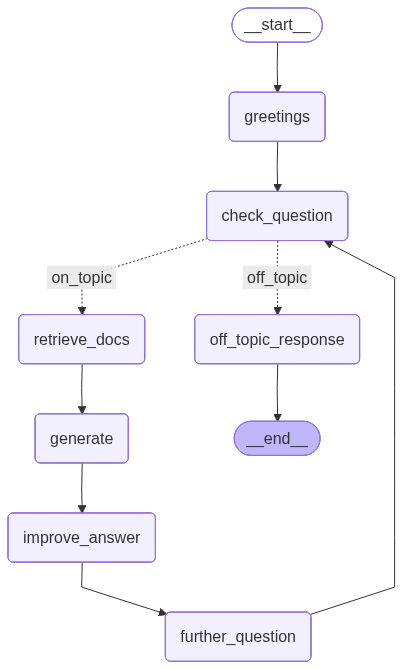

In [ ]:
# Preview the workflow
display(Image(app.get_graph(xray = True).draw_mermaid_png()))

Testing the App

In [ ]:
result = app.invoke({'start': True}, {'recursion_limit': 50})

Hello! Welcome to the restaurant. I will be your waiter. How can I help you?
Give me a vegetarian reco


I recommend the Vegetarian Soup, which features paksoy, bamboo, mushrooms, and a medley of vegetables, or the Vegetable Gyoza for a delightful bite. Both are popular choices! Would you like to hear more about the ingredients or preparation of either dish?


Have any deserts?


Yes, we have a delightful selection of desserts! You can enjoy a Banana & Chocolate Crepe, Peanut Mochi, or Green Tea Mochi. Additionally, we offer Iced Mochis in Almond & Salted Caramel or Pineapple & Coconut flavors. Would you like to know more about any specific dessert?


sounds good

Happy to help


# Agentic RAG Recap - Key Learnings and Next Steps

We just have built a fully functional Agenti system that can handle dynamic conversation retrieved documents and generate response.

The digital waiter shows how combining retrival and intelligent agents creates more natural interactions.

## What have we learned?

1. The Basics of AI Agents

* We learned how ai agents interact with users, make autonomous decisions, and manage input to adapt responses.

2. Retrival plus Generation

* This enabled our agent to fetch relevant documents and create accurate, context-based response-this is the core of RAG

3. Dynamic workflow with State Mangement

* A key advanvement was using TypeDict to manage state, track conversations, and remember user preferences for coherent, multi-turn interactions.

4. Handling Off-Topic and Recursive Queries

We equipped the agent to manage off-topic questions and avoid loops, redirecting irrelevant queries back to the main topic.

5. Improving Generated REsponse

System refines its answers to ensure they are friendly and relevant, improving interaction quality.

There components allow our digital waiter to respond intelligently, adapting to user input for personalized, smooth experience.

## Some ideas for improvement

1. Enhanced Memory Capabilitites

Long_term memory would help it remeber details from past sessions, benefiting returning users.

Adding user profiles is also a good idea for personalize future interactions.

2. Improved context Awareness

An advanced implementation could give the agent semantic understanding, enabling it to handle complex, nuanced queries.
Sentiment analysis is also a great indea to enhance user experience.

3. Multimodal Capabilities

You could enhance the agent by adding multimodal inputs like voice or images.

4. Expanding the Knowledge Base

To improve versatility, the system could be upgraded to access external source like APIs or live data feeds.

Finally, with a strong foundation in conversation dynamics, response generation, and memory management, you can now develop various applications, from customer srevice bots to personal assistants.